Vanishing and exploding gradients

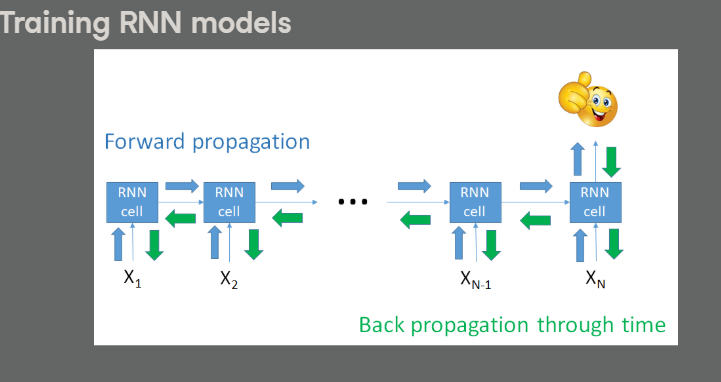

Exploding gradient problem

In [ ]:
# Create a Keras model with one hidden Dense layer
model = Sequential()
model.add(Dense(25, input_dim=20, activation='relu', kernel_initializer=he_uniform(seed=42)))
model.add(Dense(1, activation='linear'))

# Compile and fit the model
model.compile(loss='mean_squared_error', optimizer=SGD(learning_rate=0.01, momentum=0.9))
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, verbose=0)

# See Mean Square Error for train and test data
train_mse = model.evaluate(X_train, y_train, verbose=0)
test_mse = model.evaluate(X_test, y_test, verbose=0)

# Print the values of MSE
print('Train: %.3f, Test: %.3f' % (train_mse,test_mse))

In [ ]:
# Create a Keras model with one hidden Dense layer
model = Sequential()
model.add(Dense(25, input_dim=20, activation='relu', kernel_initializer=he_uniform(seed=42)))
model.add(Dense(1, activation='linear'))

# Compile and fit the model
model.compile(loss='mean_squared_error', optimizer=SGD(learning_rate=0.01, momentum=0.9, clipvalue=3.0))
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, verbose=0)

# See Mean Square Error for train and test data
train_mse = model.evaluate(X_train, y_train, verbose=0)
test_mse = model.evaluate(X_test, y_test, verbose=0)

# Print the values of MSE
print('Train: %.3f, Test: %.3f' % (train_mse, test_mse))

Vanishing gradient problem

GRU and LSTM cells

- Usage in Keras

In [ ]:
# Import the layers
from tensorflow import keras
from tensorflow.keras.layers import GRU, LSTM
# add the layers to a model
model.add(GRU(units=128, return_sequences=True, name='GRU layer'))
model.add(LSTM(units=64, return_sequences=False, name='LSTM layer'))

### GRU cells are better than simpleRNN

In [ ]:
# Import the modules
from tensorflow.keras.layers import GRU, Dense

# Print the old and new model summaries
SimpleRNN_model.summary()
gru_model.summary()

# Evaluate the models' performance (ignore the loss value)
_, acc_simpleRNN = SimpleRNN_model.evaluate(X_test, y_test, verbose=0)
_, acc_GRU = gru_model.evaluate(X_test, y_test, verbose=0)

# Print the results
print("SimpleRNN model's accuracy:\t{0}".format(acc_simpleRNN))
print("GRU model's accuracy:\t{0}".format(acc_GRU))

Stacking RNN layers

In [ ]:
# Import the LSTM layer
from tensorflow.keras.layers import LSTM

# Build model
model = Sequential()
model.add(LSTM(units=128, input_shape=(None, 1), return_sequences=True))
model.add(LSTM(units=128, return_sequences=True))
model.add(LSTM(units=128, return_sequences=False))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Load pre-trained weights
model.load_weights('lstm_stack_model_weights.h5')

print("Loss: %0.04f\nAccuracy: %0.04f" % tuple(model.evaluate(X_test, y_test, verbose=0)))